# SSL-Spatial Supervisor-Revision Pipeline (local, one notebook, watch it run)



## Review point -> part map

| Part | Review point(s) | What it does |
|---|---|---|
| Setup | -- | Package check, data verification, GPU check. |
| 1. Ten-method comparison | **#2** (scope/ten-method zoo), **#3** (3->20 seeds) | Runs the full ten-method comparison at 20 seeds for the first time ever. Reframes it explicitly as companion/appendix material. |
| 2. Main sweep, 20 seeds + CIs | **#3** | Re-runs the main synthetic sweep, WILDS, and the three real-world datasets at 20 seeds with bootstrap CIs on every drop and the divergence-accuracy correlation. |
| 3. H4 ablation | **#1** | Isolates which component of the 3-part distribution-aware framework causes the regression the review flagged. |
| 4. Domain-adversarial strengthening | **#1** | Tests a learned fix for what Part 3 found broken -- the "strengthen, don't just concede" attempt the review asked for. |
| 5. Changepoint re-analysis | **#3** | Directly answers the review's complaint that the headline breakpoint range is generously framed given how wide some methods' CIs actually are. |
| 6. Real-data claims synthesis | **#4** | Pulls Parts 1 and 2's real-dataset results together and drafts calibrated language for what housing/WILDS support vs. the rest. |
| 7. Scope and venue notes | **#2** | Not code -- a structured discussion of the "pick a spine" restructuring options, for you to decide, not something decided for you. |

## Manuscript coverage


| Manuscript item | Caption / content | Produced in |
|---|---|---|
| Table 1, Figures 1-2 | Synthetic accuracy/gap vs mismatch, 3 baselines | Part 2, §2.1 |
| Table 2, Figure 3 | Divergence-accuracy correlation, scatter | Part 2, §2.1 (fig 3) + §2.4 (table) |
| Figure 15 | Correlation bars with bootstrap CI | Part 2, §2.4 |
| Table 3 | Calibration (ECE) in/out-of-region | Part 2, §2.1 |
| Table 4, Figures 4-5 | WILDS accuracy/gap vs severity | Part 2, §2.2 |
| Table 5, Figure 8 | Real-world accuracy vs severity (3 datasets) | Part 2, §2.3 |
| Table 8, Figure 14 | Changepoint breakpoints + fitted curves | Part 5 |
| Table S-framework, Figure 9 | H4 framework 3-way comparison | Part 3 (superset: 5-way ablation) |
| Table S-spatial, Figure 13 | Spatial-models drop, 5 methods | Part 1 (superset: full 10-method) |
| Figures 10-12 | Method-family accuracy curves, all 5 datasets | Part 1 |
| Figures 6, 7 | Sample WILDS patches; dataset geographic coverage | Not regenerated -- illustrative, unaffected by seed count |

**On compute:** Parts 1 and 4 are `torch`-based and benefit from a GPU if
your machine has one (`ssl_spatial.models._device.DEVICE` picks it up
automatically) -- otherwise they'll run on CPU, just slower. Both
checkpoint progress to disk (`resume=True`), so if you need to stop and
resume later, just re-run that part's cell.

Nothing in this notebook edits `manuscript/main/main.tex` or
`supplementary.tex`, and no target venue is chosen -- both are decisions
for you (Part 7 lays out the options).

---
## Setup (run once)

In [1]:
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO_ROOT / "src"))
print("REPO_ROOT:", REPO_ROOT)

REPO_ROOT: c:\Users\Lenovo\Desktop\SSL


In [2]:
# Quick check that every extra dependency this pipeline needs is importable.
# If anything is missing, uncomment the pip install line below and re-run --
# it's idempotent/quick if everything is already satisfied.
missing_pkgs = []
for pkg in ["yaml", "docx", "wilds", "requests", "urllib3", "openpyxl", "gstools", "pwlf", "torch"]:
    try:
        __import__(pkg)
    except ImportError:
        missing_pkgs.append(pkg)
if missing_pkgs:
    print(f"Missing: {missing_pkgs} -- run: %pip install -r {REPO_ROOT / 'requirements.txt'}")
else:
    print("All required packages importable.")

# %pip install -q -r {REPO_ROOT / "requirements.txt"}

Microsoft Visual C++ Redistributable is not installed, this may lead to the DLL load failure.
It can be downloaded at https://aka.ms/vs/17/release/vc_redist.x64.exe
All required packages importable.


In [3]:
expected = [
    "data/real_world/housing/us_county_centroids.csv",
    "data/real_world/socioeconomic/unemp_income.csv",
    "data/real_world/socioeconomic/poverty.xlsx",
    "data/real_world/socioeconomic/population.xlsx",
    "data/real_world/socioeconomic/edu.xlsx",
    "data/real_world/air_quality/annual_conc_by_monitor_2023.csv",
    "data/wilds_povertymap/dhs_metadata.csv",
    "data/wilds_povertymap/feature_cache_foldA_cpc90_u300_ti150_to150_ps0.npz",
]
missing = [p for p in expected if not (REPO_ROOT / p).exists()]
if missing:
    raise FileNotFoundError(f"Missing data files: {missing}")
print(f"All {len(expected)} expected data files present.")

All 8 expected data files present.


In [ ]:
import time

import numpy as np
import pandas as pd
import yaml

from ssl_spatial.metrics.bootstrap import bootstrap_ci_drop
from ssl_spatial.metrics.divergence import kl_divergence_kde, mmd_rbf, wasserstein_marginal
from ssl_spatial.metrics.evaluation import evaluate_classifier
from ssl_spatial.models._device import DEVICE
from ssl_spatial.models.baselines import BASELINE_METHODS
from ssl_spatial.models.distribution_aware import DISTRIBUTION_AWARE_METHODS
from ssl_spatial.plotting import (
    BASELINE_COLOR, FONT_LABEL, FONT_LEGEND, FONT_TICK, FONT_TITLE, INK_PRIMARY, INK_SECONDARY,
    METHOD_COLORS, METHOD_FAMILIES, METHOD_LABELS, PALETTE, new_figure, panel_label, plot_method_lines, savefig,
)

pd.set_option("display.width", 120)

FIG_DIR = REPO_ROOT / "figures"
FIG_DIR.mkdir(exist_ok=True)

DATASET_ORDER = ["synthetic", "wilds", "housing", "socioeconomic", "air_quality"]
DATASET_LABELS = {"synthetic": "Synthetic", "wilds": "PovertyMap-WILDS", "housing": "Housing",
                   "socioeconomic": "Socio-economic", "air_quality": "Air quality"}
BASE_METHODS = ["supervised_only", "self_training", "label_propagation"]

print("Device ssl_spatial will use:", DEVICE)
if DEVICE.type != "cuda":
    print("No GPU detected -- Parts 1 and 4 will run on CPU (slower but fine).")

---
# Part 1: Ten-Method Comparison at 20 Seeds

Review points **#2** (scope sprawl -- "the ten-method zoo" should be demoted
to a section or companion paper) and **#3** (statistical rigor -- this
comparison specifically is the one sweep in the whole study that has
*never* been re-run at 20 seeds).

Runs `configs/spatial_methods_comparison_v2.yaml` -- the ten-method
comparison (baselines, re-weighted self-training, Mean Teacher, FixMatch,
GCN, spatial-kernel GCN, GNNWR, Fouedjio geostatistical SSL) across all
five datasets, at 20 seeds instead of 3 (6 severities x 20 seeds x 10
methods x 5 datasets = 6,000 fits). Several methods are `torch`-based.

Produces the manuscript's Supplementary Table S-spatial, Table S-framework's
sibling data, and Figures 9-13 -- everything in Supplementary Section S2.2
plus the S2.1 framework comparison's 5-dataset scope.

**Expect this to take a while.** `spatial_methods_comparison.run()`
checkpoints each dataset's rows to `results/spatial_methods_comparison_v2.<dataset>.partial.csv`
as soon as that dataset finishes (`resume=True` default), so if you need to
stop, just re-run the cell below and it picks up where it left off.

This part doesn't pre-write a "here's what we found" discussion -- unlike
Parts 2-4, these numbers have never been computed before, so the closing
cells compute the discussion points programmatically from whatever your run
actually produces.

In [6]:
from ssl_spatial.experiments import spatial_methods_comparison as smc

CONFIG_PATH_TEN_METHOD = REPO_ROOT / "configs" / "spatial_methods_comparison_v2.yaml"
METHOD_ORDER = ["supervised_only", "self_training", "label_propagation", "reweighted_self_training",
                "mean_teacher", "fixmatch", "gcn", "spatial_gnn", "gnnwr", "geostatistical_ssl"]

start = time.time()
df = smc.run(str(CONFIG_PATH_TEN_METHOD), resume=True)
print(f"\nTotal wall time: {(time.time() - start) / 60:.1f} min")
print(f"{len(df)} rows: {df['dataset'].nunique()} datasets x {df['mismatch_alpha'].nunique()} alphas x "
      f"{df['seed'].nunique()} seeds x {df['method'].nunique()} methods")

=== synthetic ===
[synthetic] [5/120] combos done (111.8s elapsed)
[synthetic] [10/120] combos done (236.7s elapsed)
[synthetic] [15/120] combos done (374.4s elapsed)
[synthetic] [20/120] combos done (504.1s elapsed)
[synthetic] [25/120] combos done (680.1s elapsed)
[synthetic] [30/120] combos done (837.4s elapsed)
[synthetic] [35/120] combos done (987.7s elapsed)
[synthetic] [40/120] combos done (1131.4s elapsed)
[synthetic] [45/120] combos done (1290.5s elapsed)
[synthetic] [50/120] combos done (1440.3s elapsed)
[synthetic] [55/120] combos done (1568.8s elapsed)
[synthetic] [60/120] combos done (1687.8s elapsed)
[synthetic] [65/120] combos done (1812.7s elapsed)
[synthetic] [70/120] combos done (1942.5s elapsed)
[synthetic] [75/120] combos done (2067.0s elapsed)
[synthetic] [80/120] combos done (2185.7s elapsed)
[synthetic] [85/120] combos done (2305.9s elapsed)
[synthetic] [90/120] combos done (2424.7s elapsed)
[synthetic] [95/120] combos done (2546.5s elapsed)
[synthetic] [100/120]


Total wall time: 181.1 min
6000 rows: 5 datasets x 6 alphas x 20 seeds x 10 methods


[air_quality] [120/120] combos done (1575.1s elapsed)
Checkpointed air_quality to C:\Users\Lenovo\Desktop\SSL\results\spatial_methods_comparison_v2.air_quality.partial.csv
Saved 6000 rows to C:\Users\Lenovo\Desktop\SSL\results\spatial_methods_comparison_v2.csv


### 1.1 Accuracy drop per method, per dataset, with bootstrap CIs

In [7]:
drop = bootstrap_ci_drop(df, group_cols=["dataset", "method"], value_col="accuracy_out_region",
                          alpha_col="mismatch_alpha", lo=0.0, hi=1.0, n_boot=200, seed=0)
drop["drop_pp"] = drop["drop"] * 100
drop["ci_low_pp"] = drop["ci_low"] * 100
drop["ci_high_pp"] = drop["ci_high"] * 100
drop["dataset"] = pd.Categorical(drop["dataset"], categories=DATASET_ORDER, ordered=True)
drop["method"] = pd.Categorical(drop["method"], categories=METHOD_ORDER, ordered=True)
drop = drop.sort_values(["dataset", "method"])

table = drop.copy()
table["method"] = table["method"].map(METHOD_LABELS)
table["dataset"] = table["dataset"].map(DATASET_LABELS)
table["drop (95% CI)"] = table.apply(
    lambda r: f"{r['drop_pp']:.2f} [{r['ci_low_pp']:.2f}, {r['ci_high_pp']:.2f}]", axis=1)
table[["dataset", "method", "drop (95% CI)"]].reset_index(drop=True)

,dataset,method,drop (95% CI)
0,Synthetic,Supervised-only,"4.97 [2.30, 7.82]"
1,Synthetic,Self-training,"2.42 [0.43, 4.82]"
2,Synthetic,Label propagation,"2.65 [0.61, 4.69]"
3,Synthetic,Reweighted self-training,"3.35 [1.20, 6.23]"
4,Synthetic,Mean Teacher,"0.63 [-0.90, 2.42]"
5,Synthetic,FixMatch,"4.97 [1.01, 9.49]"
6,Synthetic,GCN,"2.23 [0.25, 4.14]"
7,Synthetic,Spatial GNN,"2.10 [0.07, 3.80]"
8,Synthetic,GNNWR,"24.17 [20.51, 28.12]"
9,Synthetic,Geostatistical SSL (Fouedjio),"8.85 [4.65, 12.88]"


### 1.1b Manuscript-format Table S-spatial (point estimates, no CI)

The exact 5-method x 5-dataset subset (supervised-only + the four spatially
explicit models) in the manuscript's table layout, for direct comparison
against the current `supplementary.tex` numbers.

In [8]:
spatial_methods = METHOD_FAMILIES["spatial"]  # supervised_only, gcn, spatial_gnn, gnnwr, geostatistical_ssl
t_spatial = drop[drop["method"].isin(spatial_methods)].pivot(index="dataset", columns="method", values="drop_pp")
t_spatial = t_spatial[spatial_methods].reindex(DATASET_ORDER)
t_spatial.columns = [METHOD_LABELS[m] for m in t_spatial.columns]
t_spatial.index = [DATASET_LABELS[d] for d in t_spatial.index]
t_spatial.loc["Average"] = t_spatial.mean()
t_spatial.round(1)

,Supervised-only,GCN,Spatial GNN,GNNWR,Geostatistical SSL (Fouedjio)
Synthetic,5.0,2.2,2.1,24.2,8.9
PovertyMap-WILDS,10.2,4.7,-0.4,3.8,10.7
Housing,12.5,-2.3,-1.0,15.6,9.6
Socio-economic,-2.5,0.0,3.7,5.6,12.1
Air quality,9.3,29.1,20.3,19.4,-4.2
Average,6.9,6.8,4.9,13.7,7.4


### 1.2 Compare against the original 3-seed comparison

`results/spatial_methods_comparison.csv` (original 3-seed run behind the
manuscript's Supplementary S2.2 table) vs. this 20-seed re-run. No
bootstrap CI on the 3-seed side -- 3 seeds is too few for a meaningful
percentile interval, which is exactly the review's point.

In [9]:
orig_ten_method = pd.read_csv(REPO_ROOT / "results" / "spatial_methods_comparison.csv")

def _point_drop(frame, group_cols):
    means = frame.groupby(group_cols + ["mismatch_alpha"])["accuracy_out_region"].mean().unstack("mismatch_alpha")
    return (means[0.0] - means[1.0]).rename("drop_pp_3seed") * 100

orig_drop = _point_drop(orig_ten_method, ["dataset", "method"]).reset_index()

comparison = drop.merge(orig_drop, on=["dataset", "method"], how="left")
comparison["movement_pp"] = (comparison["drop_pp"] - comparison["drop_pp_3seed"]).round(2)
comparison_display = comparison.copy()
comparison_display["method"] = comparison_display["method"].map(METHOD_LABELS)
comparison_display["dataset"] = comparison_display["dataset"].map(DATASET_LABELS)
comparison_display[["dataset", "method", "drop_pp_3seed", "drop_pp", "ci_low_pp", "ci_high_pp", "movement_pp"]]\
    .round(2).sort_values("movement_pp", key=abs, ascending=False).reset_index(drop=True)

,dataset,method,drop_pp_3seed,drop_pp,ci_low_pp,ci_high_pp,movement_pp
0,Air quality,Label propagation,29.05,13.50,9.43,18.36,-15.55
1,PovertyMap-WILDS,Geostatistical SSL (Fouedjio),-2.67,10.73,6.23,15.24,13.40
2,Synthetic,FixMatch,16.78,4.97,1.01,9.49,-11.81
3,Air quality,FixMatch,22.86,12.43,8.49,16.29,-10.43
4,Air quality,Supervised-only,19.52,9.29,5.92,12.80,-10.24
5,Air quality,Self-training,15.24,5.14,0.42,10.53,-10.10
6,PovertyMap-WILDS,Reweighted self-training,3.11,11.90,5.60,18.45,8.79
7,Air quality,Mean Teacher,21.90,15.71,11.99,19.94,-6.19
8,Housing,GNNWR,21.78,15.65,11.87,20.07,-6.13
9,PovertyMap-WILDS,FixMatch,6.22,0.13,-3.27,3.97,-6.09


### 1.3 Drop figures, faceted by method family (Figure 13 equivalent)

Following `plotting.py`'s convention for this comparison: never draw all ten
methods on one axis, facet by family instead -- baselines, modern
consistency-based SSL, and spatially explicit models. The "spatially
explicit models" panel below (`fig13`) directly overwrites the manuscript's Figure 13.

In [ ]:
def plot_family(family_name, methods, fname):
    fig, ax = new_figure(figsize=(10, 5.3))
    x = np.arange(len(DATASET_ORDER))
    width = 0.8 / len(methods)
    for i, method in enumerate(methods):
        sub = drop[drop["method"] == method].set_index("dataset").reindex(DATASET_ORDER)
        offset = (i - (len(methods) - 1) / 2) * width
        ax.bar(x + offset, sub["drop_pp"], width, color=METHOD_COLORS[method], label=METHOD_LABELS[method],
               yerr=[sub["drop_pp"] - sub["ci_low_pp"], sub["ci_high_pp"] - sub["drop_pp"]],
               capsize=2, error_kw={"linewidth": 0.8, "ecolor": INK_SECONDARY})
    ax.axhline(0, color=BASELINE_COLOR, linewidth=1)
    ax.set_xticks(x)
    ax.set_xticklabels([DATASET_LABELS[d] for d in DATASET_ORDER], fontsize=FONT_TICK)
    ax.set_ylabel("Accuracy drop, alpha=0 to alpha=1 (pp)", fontsize=FONT_LABEL, color=INK_SECONDARY)
    ax.legend(frameon=False, fontsize=FONT_LEGEND, labelcolor=INK_SECONDARY, ncol=2, loc="upper left")
    ax.set_title(family_name, fontsize=FONT_TITLE, color=INK_PRIMARY)
    savefig(fig, FIG_DIR / fname)

plot_family("Baselines", METHOD_FAMILIES["baselines"], "fig18_ten_method_v2_baselines.png")
plot_family("Modern consistency-based SSL", METHOD_FAMILIES["modern_ssl"], "fig19_ten_method_v2_modern_ssl.png")
plot_family("Spatially explicit models", METHOD_FAMILIES["spatial"], "fig13_h3_spatial_drop_comparison.png")


### 1.4 Accuracy-vs-severity curves (Figures 10-12)

The manuscript's supplementary figures show full accuracy-vs-severity
curves, not just the endpoint drop -- one panel per dataset, one figure per
method family, using the same `plot_method_lines` helper the original
`notebooks/spatial_methods_comparison.ipynb` used.

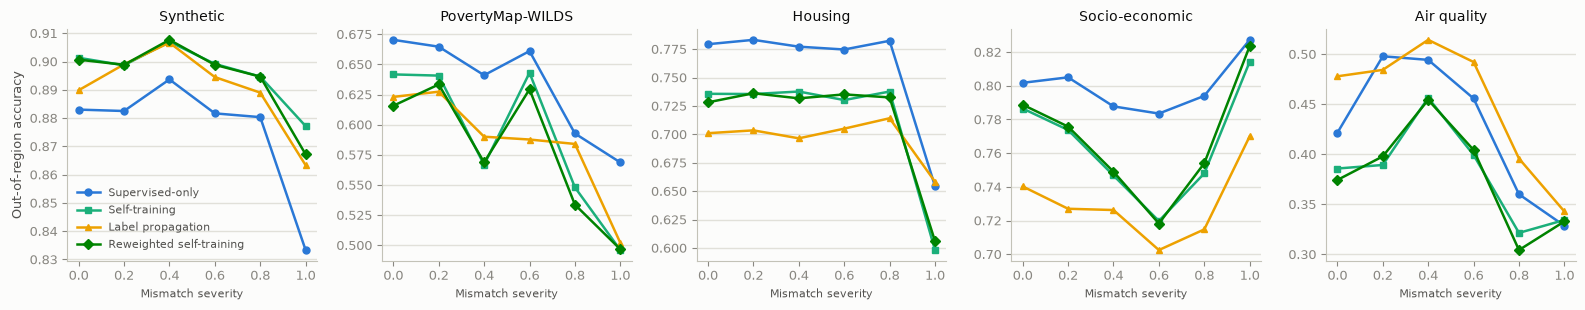

In [11]:
fig, axes = new_figure(figsize=(16, 3.2), ncols=5, sharey=False)
for ax, dataset in zip(axes, DATASET_ORDER):
    sub = df[df["dataset"] == dataset]
    plot_method_lines(ax, sub, "mismatch_alpha", "accuracy_out_region", METHOD_FAMILIES["baselines"],
                       legend=(dataset == "synthetic"))
    ax.set_title(DATASET_LABELS[dataset], fontsize=10, color="#0b0b0b")
    ax.set_xlabel("Mismatch severity", fontsize=8, color="#52514e")
axes[0].set_ylabel("Out-of-region accuracy", fontsize=9, color="#52514e")
savefig(fig, FIG_DIR / "fig10_baselines_all_datasets.png")

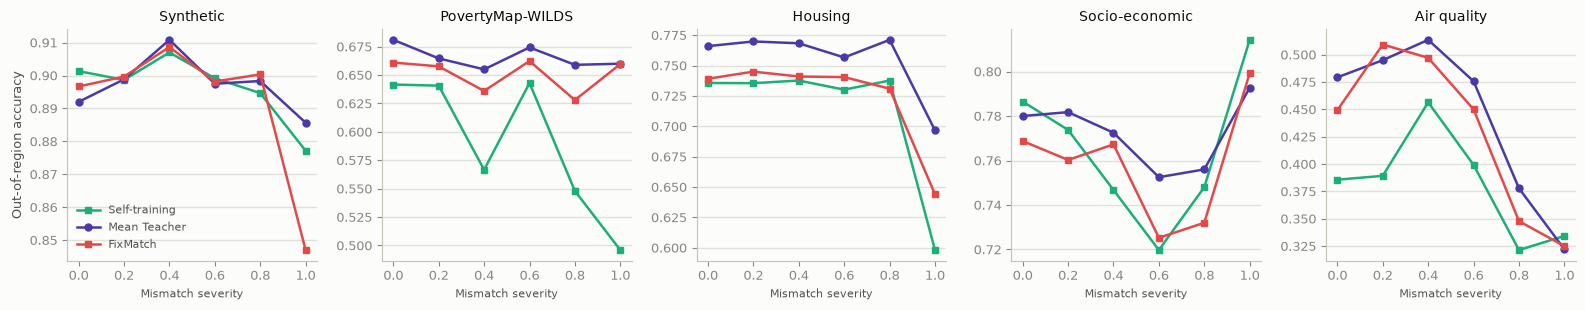

In [12]:
fig, axes = new_figure(figsize=(16, 3.2), ncols=5, sharey=False)
for ax, dataset in zip(axes, DATASET_ORDER):
    sub = df[df["dataset"] == dataset]
    plot_method_lines(ax, sub, "mismatch_alpha", "accuracy_out_region", METHOD_FAMILIES["modern_ssl"],
                       legend=(dataset == "synthetic"))
    ax.set_title(DATASET_LABELS[dataset], fontsize=10, color="#0b0b0b")
    ax.set_xlabel("Mismatch severity", fontsize=8, color="#52514e")
axes[0].set_ylabel("Out-of-region accuracy", fontsize=9, color="#52514e")
savefig(fig, FIG_DIR / "fig11_modern_ssl_all_datasets.png")

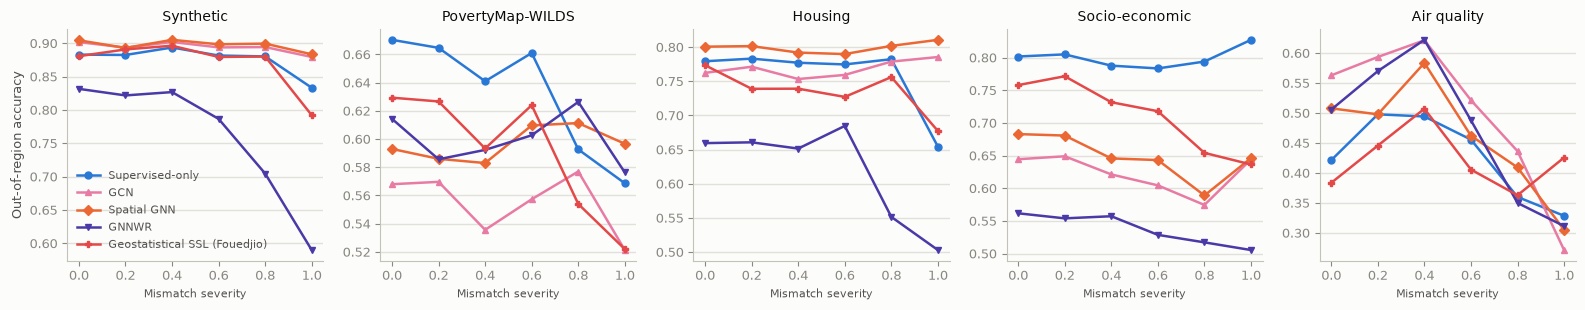

In [13]:
fig, axes = new_figure(figsize=(16, 3.2), ncols=5, sharey=False)
for ax, dataset in zip(axes, DATASET_ORDER):
    sub = df[df["dataset"] == dataset]
    plot_method_lines(ax, sub, "mismatch_alpha", "accuracy_out_region", METHOD_FAMILIES["spatial"],
                       legend=(dataset == "synthetic"))
    ax.set_title(DATASET_LABELS[dataset], fontsize=10, color="#0b0b0b")
    ax.set_xlabel("Mismatch severity", fontsize=8, color="#52514e")
axes[0].set_ylabel("Out-of-region accuracy", fontsize=9, color="#52514e")
savefig(fig, FIG_DIR / "fig12_spatial_models_all_datasets.png")

In [ ]:
overall_mean = drop.groupby("method", observed=True)["drop_pp"].mean().sort_values(ascending=False)
print("Mean accuracy drop across all 5 datasets, 20-seed re-run (most to least fragile):")
for method, val in overall_mean.items():
    print(f"  {METHOD_LABELS[method]:32s} {val:6.2f} pp")

print("\nBiggest movers vs the original 3-seed numbers (|20-seed - 3-seed| > 3pp):")
movers = comparison[comparison["movement_pp"].abs() > 3.0].copy()
movers["method"] = movers["method"].map(METHOD_LABELS)
movers["dataset"] = movers["dataset"].map(DATASET_LABELS)
if len(movers):
    for _, r in movers.sort_values("movement_pp", key=abs, ascending=False).iterrows():
        print(f"  {r['dataset']:18s} {r['method']:32s} {r['drop_pp_3seed']:6.2f} -> {r['drop_pp']:6.2f} pp "
              f"(moved {r['movement_pp']:+.2f} pp)")
else:
    print("  none -- every method/dataset combination is within 3pp of its 3-seed estimate.")

print("\nWidest CIs (least precise estimates -- usually the smallest-labelled-set datasets):")
widest = drop.copy()
widest["ci_width"] = widest["ci_high_pp"] - widest["ci_low_pp"]
widest = widest.sort_values("ci_width", ascending=False).head(5)
for _, r in widest.iterrows():
    print(f"  {DATASET_LABELS[r['dataset']]:18s} {METHOD_LABELS[r['method']]:32s} "
          f"CI width={r['ci_width']:.2f}pp")


Mean accuracy drop across all 5 datasets, 20-seed re-run (most to least fragile):
  GNNWR                             13.73 pp
  Geostatistical SSL (Fouedjio)      7.43 pp
  Supervised-only                    6.87 pp
  GCN                                6.75 pp
  Self-training                      6.62 pp
  Label propagation                  5.91 pp
  Reweighted self-training           5.63 pp
  Spatial GNN                        4.94 pp
  Mean Teacher                       4.82 pp
  FixMatch                           4.80 pp

Biggest movers vs the original 3-seed numbers (|20-seed - 3-seed| > 3pp):
  Air quality        Label propagation                 29.05 ->  13.50 pp (moved -15.55 pp)
  PovertyMap-WILDS   Geostatistical SSL (Fouedjio)     -2.67 ->  10.73 pp (moved +13.40 pp)
  Synthetic          FixMatch                          16.78 ->   4.97 pp (moved -11.81 pp)
  Air quality        FixMatch                          22.86 ->  12.43 pp (moved -10.43 pp)
  Air quality        Supe

---
# Part 2: Main-Sweep Statistical-Rigor Revision

Review point **#3**: the manuscript's main synthetic sweep, the WILDS
benchmark, and the three real-world datasets all ran at only 3 seeds, with
no confidence interval on any accuracy/drop number, and the pooled Pearson
correlation across all 324 synthetic runs ignored the nested seed x
lengthscale x nonstationarity structure -- pseudo-replication that inflates
apparent precision.

Re-runs every one of those sweeps at 20 seeds instead of 3 (`configs/*_v2.yaml`,
otherwise identical to the originals), attaches a 95% seed-cluster bootstrap
CI to every accuracy-drop number, and re-derives the divergence-vs-accuracy
correlation table with the same CI treatment. All sklearn-only -- fast even
on CPU. Produces Tables 1-5 and Figures 1-5, 8, 15.

**On WILDS:** `wilds_benchmark.run()` reads raw satellite images from disk.
This repo already has those cached locally, but the cell below uses the
568KB pre-extracted feature cache instead (same one `spatial_methods_comparison.py`
uses) so this notebook behaves identically whether or not the 1.1GB image
cache happens to be present -- same methods, same metrics, same output
schema, just a different feature-loading step.

### 2.1 Synthetic main sweep (Table 1), 20 seeds

`configs/controlled_experiment_v2.yaml`: identical to `controlled_experiment.yaml`
except 3 -> 20 seeds (2,160 rows instead of 324).

In [15]:
from ssl_spatial.experiments.controlled_experiment import run as run_controlled

synth = run_controlled(str(REPO_ROOT / "configs" / "controlled_experiment_v2.yaml"))
drop_synth = bootstrap_ci_drop(synth, group_cols=["method"], value_col="accuracy_out_region",
                                alpha_col="mismatch_alpha", n_boot=200, seed=0)
drop_synth["drop_pp"] = (drop_synth["drop"] * 100).round(2)
drop_synth["95% CI (pp)"] = drop_synth.apply(
    lambda r: f"[{r['ci_low']*100:.2f}, {r['ci_high']*100:.2f}]", axis=1)
drop_synth["drop_pp (original, 3 seeds)"] = drop_synth["method"].map(
    {"self_training": 8.8, "supervised_only": 6.3, "label_propagation": 4.9})
drop_synth.sort_values("drop_pp", ascending=False)[
    ["method", "drop_pp", "95% CI (pp)", "drop_pp (original, 3 seeds)"]].reset_index(drop=True)

c:\Users\Lenovo\Desktop\SSL\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\Lenovo\Desktop\SSL\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\Lenovo\Desktop\SSL\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\Lenovo\Desktop\SSL\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and w

,method,drop_pp,95% CI (pp),"drop_pp (original, 3 seeds)"
0,supervised_only,6.16,"[4.54, 7.83]",6.3
1,self_training,5.60,"[3.86, 7.37]",8.8
2,label_propagation,4.15,"[2.49, 5.81]",4.9


### 2.1b Table 3: calibration (expected calibration error), in- and out-of-region

In [16]:
ece = synth.groupby(["method", "mismatch_alpha"])[["ece_in_region", "ece_out_region"]].mean()
t3 = pd.DataFrame({
    "ECE in-region (a=0)": ece.xs(0.0, level="mismatch_alpha")["ece_in_region"],
    "ECE in-region (a=1)": ece.xs(1.0, level="mismatch_alpha")["ece_in_region"],
    "ECE out-of-region (a=0)": ece.xs(0.0, level="mismatch_alpha")["ece_out_region"],
    "ECE out-of-region (a=1)": ece.xs(1.0, level="mismatch_alpha")["ece_out_region"],
}).round(3)
t3.index = [METHOD_LABELS[m] for m in t3.index]
t3

,ECE in-region (a=0),ECE in-region (a=1),ECE out-of-region (a=0),ECE out-of-region (a=1)
Label propagation,0.038,0.035,0.035,0.073
Self-training,0.082,0.070,0.075,0.137
Supervised-only,0.044,0.046,0.039,0.080


### 2.1c Figures 1-3: accuracy/gap vs mismatch, and divergence vs accuracy

Same style as `ssl_spatial.experiments.plot_results` (the original 3-seed
figure generator), rewritten inline here so the figures display in the
notebook rather than only saving silently to disk.

In [ ]:
# Figure 1: accuracy vs mismatch, faceted by non-stationarity level
stat_levels = sorted(synth["nonstationarity_strength"].unique())
fig, axes = new_figure(figsize=(11, 4.8), ncols=len(stat_levels), sharey=True)
axes = np.atleast_1d(axes)
for letter, ax, stat in zip("abcdefgh", axes, stat_levels):
    sub = synth[synth["nonstationarity_strength"] == stat]
    for method in BASE_METHODS:
        g = sub[sub["method"] == method].groupby("mismatch_alpha")["accuracy_out_region"].mean()
        ax.plot(g.index, g.values, marker="o", markersize=6, linewidth=2,
                color=METHOD_COLORS[method], label=METHOD_LABELS[method], zorder=3)
    title = "Stationary label process" if stat == 0 else f"Non-stationary (strength={stat})"
    ax.set_title(title, fontsize=FONT_TITLE, color=INK_PRIMARY, loc="left")
    ax.set_xlabel("Mismatch severity (alpha)", fontsize=FONT_LABEL, color=INK_SECONDARY)
    panel_label(ax, letter)
axes[0].set_ylabel("Out-of-region accuracy", fontsize=FONT_LABEL, color=INK_SECONDARY)
axes[0].legend(frameon=False, fontsize=FONT_LEGEND, loc="lower left", labelcolor=INK_SECONDARY)
savefig(fig, FIG_DIR / "fig1_accuracy_vs_mismatch.png")


In [ ]:
# Figure 2: spatial generalisation gap vs mismatch
fig, ax = new_figure(figsize=(7, 4.5))
for method in BASE_METHODS:
    g = synth[synth["method"] == method].groupby("mismatch_alpha")["spatial_generalisation_gap"].mean()
    ax.plot(g.index, g.values, marker="o", markersize=6, linewidth=2,
            color=METHOD_COLORS[method], label=METHOD_LABELS[method], zorder=3)
ax.axhline(0, color=BASELINE_COLOR, linewidth=1, zorder=1)
ax.set_xlabel("Mismatch level", fontsize=FONT_LABEL, color=INK_SECONDARY)
ax.set_ylabel("Spatial generalisation gap", fontsize=FONT_LABEL, color=INK_SECONDARY)
ax.legend(frameon=False, fontsize=FONT_LEGEND, loc="upper left", labelcolor=INK_SECONDARY)
savefig(fig, FIG_DIR / "fig2_spatial_gap_vs_mismatch.png")


In [ ]:
# Figure 3: measured divergence (MMD) vs out-of-region accuracy
fig, ax = new_figure(figsize=(7, 4.5))
for method in BASE_METHODS:
    sub = synth[synth["method"] == method]
    ax.scatter(sub["mmd"], sub["accuracy_out_region"], s=26, alpha=0.6,
               color=METHOD_COLORS[method], label=METHOD_LABELS[method], zorder=3, edgecolors="none")
ax.set_xlabel("Measured mismatch (MMD)", fontsize=FONT_LABEL, color=INK_SECONDARY)
ax.set_ylabel("Out-of-region accuracy", fontsize=FONT_LABEL, color=INK_SECONDARY)
ax.legend(frameon=False, fontsize=FONT_LEGEND, loc="lower left", labelcolor=INK_SECONDARY)
savefig(fig, FIG_DIR / "fig3_divergence_vs_accuracy.png")


### 2.2 PovertyMap-WILDS (Table 4, Figures 4-5), 20 seeds, sourced from the feature cache

`configs/wilds_benchmark_v2.yaml`: identical except 3 -> 20 seeds (360 rows
instead of 54).

In [20]:
from ssl_spatial.data.wilds_poverty import (
    all_pool_indices, build_pools, download_metadata, labelled_indices_for_alpha,
    n_active_countries, reduce_dimensionality,
)

_ALL_METHODS = {**BASELINE_METHODS, **DISTRIBUTION_AWARE_METHODS}


def run_wilds_from_cache(config_path) -> pd.DataFrame:
    with open(config_path) as f:
        cfg = yaml.safe_load(f)
    data_dir = REPO_ROOT / cfg["data_dir"]
    wcfg, sweep, methods = cfg["wilds"], cfg["sweep"], cfg["methods"]

    metadata = download_metadata(data_dir)
    pools = build_pools(metadata, fold=wcfg["fold"], candidate_per_country=wcfg["candidate_per_country"],
                         n_unlabelled=wcfg["n_unlabelled"], n_test_in=wcfg["n_test_in"],
                         n_test_out=wcfg["n_test_out"], seed=wcfg["pool_seed"])
    needed = all_pool_indices(pools)

    cache_path = data_dir / (f"feature_cache_fold{wcfg['fold']}_cpc{wcfg['candidate_per_country']}_"
                              f"u{wcfg['n_unlabelled']}_ti{wcfg['n_test_in']}_to{wcfg['n_test_out']}_"
                              f"ps{wcfg['pool_seed']}.npz")
    cached = np.load(cache_path)
    X_cache, valid_idx = cached["X_cache"], cached["valid_idx"]
    missing = [i for i in needed if i not in set(valid_idx.tolist())]
    if missing:
        raise FileNotFoundError(f"{len(missing)}/{len(needed)} pool indices missing from cache {cache_path}")

    wealth_median = metadata["wealthpooled"].median()
    y_all = (metadata["wealthpooled"] > wealth_median).astype(int)
    idx_to_row = {int(idx): row for row, idx in enumerate(valid_idx)}
    mean, std = X_cache.mean(axis=0), X_cache.std(axis=0) + 1e-12
    X_reduced, _pca = reduce_dimensionality((X_cache - mean) / std, n_components=cfg.get("n_pca_components", 5))

    def features_for(idx_array):
        return X_reduced[[idx_to_row[int(i)] for i in idx_array]]

    def labels_for(idx_array):
        return y_all.iloc[idx_array].to_numpy()

    X_u = features_for(pools["unlabelled_idx"])
    X_in, y_in = features_for(pools["test_in_idx"]), labels_for(pools["test_in_idx"])
    X_out, y_out = features_for(pools["test_out_idx"]), labels_for(pools["test_out_idx"])

    rows = []
    combos = [(a, s) for a in sweep["mismatch_alpha"] for s in sweep["seeds"]]
    for i, (alpha, seed) in enumerate(combos):
        labelled_idx = labelled_indices_for_alpha(pools, alpha, sweep["n_labelled"], seed)
        X_l, y_l = features_for(labelled_idx), labels_for(labelled_idx)
        kl = kl_divergence_kde(X_l, X_u)
        wass, _ = wasserstein_marginal(X_l, X_u)
        mmd = mmd_rbf(X_l, X_u)
        for method in methods:
            clf = _ALL_METHODS[method](X_l, y_l, X_u, seed=seed)
            perf = evaluate_classifier(clf, X_in, y_in, X_out, y_out)
            rows.append({
                "mismatch_alpha": alpha,
                "n_active_countries": n_active_countries(len(pools["train_countries"]), alpha),
                "seed": seed, "method": method, "kl_divergence": kl, "wasserstein": wass, "mmd": mmd,
                "n_labelled": len(labelled_idx), **perf,
            })
        if (i + 1) % 20 == 0 or (i + 1) == len(combos):
            print(f"[wilds] [{i + 1}/{len(combos)}] combos done", file=sys.stderr)

    results = pd.DataFrame(rows)
    out_path = REPO_ROOT / cfg["output_csv"]
    out_path.parent.mkdir(parents=True, exist_ok=True)
    results.to_csv(out_path, index=False)
    print(f"Saved {len(results)} rows to {out_path}", file=sys.stderr)
    return results


wilds = run_wilds_from_cache(REPO_ROOT / "configs" / "wilds_benchmark_v2.yaml")
drop_wilds = bootstrap_ci_drop(wilds, group_cols=["method"], value_col="accuracy_out_region",
                                alpha_col="mismatch_alpha", n_boot=200, seed=0)
drop_wilds["drop_pp"] = (drop_wilds["drop"] * 100).round(2)
drop_wilds["95% CI (pp)"] = drop_wilds.apply(
    lambda r: f"[{r['ci_low']*100:.2f}, {r['ci_high']*100:.2f}]", axis=1)
drop_wilds["drop_pp (original, 3 seeds)"] = drop_wilds["method"].map(
    {"self_training": 15.3, "label_propagation": 10.2, "supervised_only": 5.1})
drop_wilds.sort_values("drop_pp", ascending=False)[
    ["method", "drop_pp", "95% CI (pp)", "drop_pp (original, 3 seeds)"]].reset_index(drop=True)

c:\Users\Lenovo\Desktop\SSL\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\Lenovo\Desktop\SSL\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\Lenovo\Desktop\SSL\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\Lenovo\Desktop\SSL\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and w

,method,drop_pp,95% CI (pp),"drop_pp (original, 3 seeds)"
0,self_training,14.57,"[9.72, 21.40]",15.3
1,label_propagation,12.10,"[10.13, 14.07]",10.2
2,supervised_only,10.17,"[6.90, 13.74]",5.1


In [ ]:
# Figure 4: WILDS out-of-region accuracy vs mismatch severity
fig, ax = new_figure(figsize=(7, 4.5))
for method in BASE_METHODS:
    g = wilds[wilds["method"] == method].groupby("mismatch_alpha")["accuracy_out_region"].mean()
    ax.plot(g.index, g.values, marker="o", markersize=6, linewidth=2,
            color=METHOD_COLORS[method], label=METHOD_LABELS[method], zorder=3)
ax.set_xlabel("Mismatch severity (restricted source countries)", fontsize=FONT_LABEL, color=INK_SECONDARY)
ax.set_ylabel("Out-of-region (OOD country) accuracy", fontsize=FONT_LABEL, color=INK_SECONDARY)
ax.legend(frameon=False, fontsize=FONT_LEGEND, loc="lower left", labelcolor=INK_SECONDARY)
savefig(fig, FIG_DIR / "fig4_wilds_accuracy_vs_mismatch.png")


In [ ]:
# Figure 5: WILDS spatial generalisation gap vs mismatch severity
fig, ax = new_figure(figsize=(7, 4.5))
for method in BASE_METHODS:
    g = wilds[wilds["method"] == method].groupby("mismatch_alpha")["spatial_generalisation_gap"].mean()
    ax.plot(g.index, g.values, marker="o", markersize=6, linewidth=2,
            color=METHOD_COLORS[method], label=METHOD_LABELS[method], zorder=3)
ax.axhline(0, color=BASELINE_COLOR, linewidth=1, zorder=1)
ax.set_xlabel("Mismatch severity (restricted source countries)", fontsize=FONT_LABEL, color=INK_SECONDARY)
ax.set_ylabel("Spatial generalisation gap", fontsize=FONT_LABEL, color=INK_SECONDARY)
ax.legend(frameon=False, fontsize=FONT_LEGEND, loc="upper left", labelcolor=INK_SECONDARY)
savefig(fig, FIG_DIR / "fig5_wilds_spatial_gap_vs_mismatch.png")


### 2.3 Real-world datasets (Table 5, Figure 8), 20 seeds

`configs/{housing,socioeconomic,air_quality}_benchmark_v2.yaml`: identical
except 3 -> 20 seeds (480 rows each instead of 72).

In [23]:
from ssl_spatial.experiments.real_world_benchmark import run as run_real_world

ORIGINAL_REAL_WORLD = {
    ("housing", "supervised_only"): 11.9, ("housing", "self_training"): 10.3,
    ("housing", "label_propagation"): 2.9, ("housing", "reweighted_self_training"): 9.7,
    ("socioeconomic", "supervised_only"): -1.8, ("socioeconomic", "self_training"): -1.5,
    ("socioeconomic", "label_propagation"): -1.3, ("socioeconomic", "reweighted_self_training"): -2.3,
    ("air_quality", "supervised_only"): 18.1, ("air_quality", "self_training"): 17.1,
    ("air_quality", "label_propagation"): 29.0, ("air_quality", "reweighted_self_training"): 21.0,
}

real_world_tables = {}
real_world_raw = {}
for name in ["housing", "socioeconomic", "air_quality"]:
    _df = run_real_world(str(REPO_ROOT / "configs" / f"{name}_benchmark_v2.yaml"))
    real_world_raw[name] = _df
    d = bootstrap_ci_drop(_df, group_cols=["method"], value_col="accuracy_out_region",
                           alpha_col="mismatch_alpha", n_boot=200, seed=0)
    d["drop_pp"] = (d["drop"] * 100).round(2)
    d["95% CI (pp)"] = d.apply(lambda r: f"[{r['ci_low']*100:.2f}, {r['ci_high']*100:.2f}]", axis=1)
    d["drop_pp (original, 3 seeds)"] = d["method"].map(lambda m: ORIGINAL_REAL_WORLD[(name, m)])
    real_world_tables[name] = d.sort_values("drop_pp", ascending=False)[
        ["method", "drop_pp", "95% CI (pp)", "drop_pp (original, 3 seeds)"]].reset_index(drop=True)

print("--- Housing ---"); display(real_world_tables["housing"])
print("--- Socio-economic ---"); display(real_world_tables["socioeconomic"])
print("--- Air quality ---"); display(real_world_tables["air_quality"])

c:\Users\Lenovo\Desktop\SSL\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\Lenovo\Desktop\SSL\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\Lenovo\Desktop\SSL\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\Lenovo\Desktop\SSL\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and w

--- Housing ---


,method,drop_pp,95% CI (pp),"drop_pp (original, 3 seeds)"
0,self_training,13.75,"[12.25, 15.23]",10.3
1,supervised_only,12.50,"[11.12, 14.15]",11.9
2,reweighted_self_training,12.22,"[10.55, 13.55]",9.7
3,label_propagation,4.27,"[2.28, 6.07]",2.9


--- Socio-economic ---


,method,drop_pp,95% CI (pp),"drop_pp (original, 3 seeds)"
0,supervised_only,-2.55,"[-3.60, -1.57]",-1.8
1,self_training,-2.78,"[-4.03, -1.57]",-1.5
2,label_propagation,-2.98,"[-4.68, -1.32]",-1.3
3,reweighted_self_training,-3.47,"[-5.08, -2.17]",-2.3


--- Air quality ---


,method,drop_pp,95% CI (pp),"drop_pp (original, 3 seeds)"
0,label_propagation,13.50,"[9.43, 18.36]",29.0
1,supervised_only,9.29,"[5.92, 12.80]",18.1
2,self_training,5.14,"[0.42, 10.53]",17.1
3,reweighted_self_training,4.14,"[-0.37, 9.29]",21.0


In [ ]:
# Figure 8: real-world accuracy vs mismatch severity, faceted by dataset
REAL_METHODS = ["supervised_only", "self_training", "label_propagation", "reweighted_self_training"]
titles = {"housing": "Housing (CA counties)", "socioeconomic": "Socio-economic (US states)",
          "air_quality": "Air quality (US states)"}

fig, axes = new_figure(figsize=(16, 5), ncols=3, sharey=False)
for letter, ax, name in zip("abc", axes, ["housing", "socioeconomic", "air_quality"]):
    df_rw = real_world_raw[name]
    for method in REAL_METHODS:
        g = df_rw[df_rw["method"] == method].groupby("mismatch_alpha")["accuracy_out_region"].mean()
        ax.plot(g.index, g.values, marker="o", markersize=5, linewidth=1.8,
                color=METHOD_COLORS[method], label=METHOD_LABELS[method], zorder=3)
    ax.set_title(titles[name], fontsize=FONT_TITLE, color=INK_PRIMARY)
    ax.set_xlabel("Mismatch severity", fontsize=FONT_LABEL, color=INK_SECONDARY)
    panel_label(ax, letter)
axes[0].set_ylabel("Out-of-region accuracy", fontsize=FONT_LABEL, color=INK_SECONDARY)
axes[-1].legend(frameon=False, fontsize=FONT_LEGEND, loc="lower left", labelcolor=INK_SECONDARY)
savefig(fig, FIG_DIR / "fig8_realworld_accuracy_vs_mismatch.png")


### 2.4 Pooled divergence-vs-accuracy correlation (Table 2, Figure 15), 20 seeds + honest CIs

In [25]:
from ssl_spatial.experiments import localized_mmd_analysis_v2

localized_mmd_analysis_v2.run(
    config_path=str(REPO_ROOT / "configs" / "controlled_experiment_v2.yaml"),
    results_csv=str(REPO_ROOT / "results" / "controlled_experiment_v2.csv"),
)

corr = pd.read_csv(REPO_ROOT / "results" / "localized_mmd_comparison_v2_correlation_ci.csv")
corr["95% CI"] = corr.apply(lambda r: f"[{r['ci_low']:.3f}, {r['ci_high']:.3f}]", axis=1)
corr["r (original, 3 seeds)"] = corr["metric"].map({
    "kl_divergence": -0.67, "mmd": -0.61, "wasserstein": -0.55,
    "localized_mmd": -0.19, "kernel_weighted_local_mmd": -0.50,
})
corr[["metric", "r", "95% CI", "r (original, 3 seeds)"]].round(3)

[100/720] combos done
[200/720] combos done
[300/720] combos done
[400/720] combos done
[500/720] combos done
[600/720] combos done
[700/720] combos done
[720/720] combos done

Pooled Pearson correlation with out-of-region accuracy, 95% seed-cluster bootstrap CI (200 resamples) -- point estimate is the same naive pooled corr() as the original analysis; the CI shows how much precision survives once the seed/lengthscale/nonstationarity nesting is accounted for:
  kl_divergence                r=-0.524   95% CI=[-0.601, -0.421]
  wasserstein                  r=-0.454   95% CI=[-0.532, -0.351]
  mmd                          r=-0.475   95% CI=[-0.556, -0.378]
  localized_mmd                r=-0.282   95% CI=[-0.348, -0.203]
  kernel_weighted_local_mmd    r=-0.396   95% CI=[-0.482, -0.326]

Saved merged comparison to C:\Users\Lenovo\Desktop\SSL\results\localized_mmd_comparison_v2.csv
Saved correlation CIs to C:\Users\Lenovo\Desktop\SSL\results\localized_mmd_comparison_v2_correlation_ci.csv


,metric,r,95% CI,"r (original, 3 seeds)"
0,kl_divergence,-0.524,"[-0.601, -0.421]",-0.67
1,wasserstein,-0.454,"[-0.532, -0.351]",-0.55
2,mmd,-0.475,"[-0.556, -0.378]",-0.61
3,localized_mmd,-0.282,"[-0.348, -0.203]",-0.19
4,kernel_weighted_local_mmd,-0.396,"[-0.482, -0.326]",-0.50


In [ ]:
# Figure 15: correlation bars with 95% bootstrap CI
metric_short = {"kl_divergence": "KL divergence", "mmd": "MMD (RBF)", "wasserstein": "Wasserstein",
                 "localized_mmd": "Localised MMD\n(fixed grid)",
                 "kernel_weighted_local_mmd": "Localised MMD\n(kernel-weighted)"}
corr_plot = corr.copy()
corr_plot["label"] = corr_plot["metric"].map(metric_short)

fig, ax = new_figure(figsize=(7.5, 4.8))
x = np.arange(len(corr_plot))
ax.bar(x, corr_plot["r"], color=PALETTE[0],
       yerr=[corr_plot["r"] - corr_plot["ci_low"], corr_plot["ci_high"] - corr_plot["r"]],
       capsize=3, error_kw={"linewidth": 1, "ecolor": INK_SECONDARY})
ax.axhline(0, color=BASELINE_COLOR, linewidth=1)
ax.set_xticks(x)
ax.set_xticklabels(corr_plot["label"], fontsize=FONT_TICK - 1)
ax.set_ylabel("Pearson r with out-of-region accuracy", fontsize=FONT_LABEL, color=INK_SECONDARY)
savefig(fig, FIG_DIR / "fig15_kernel_weighted_mmd_validation.png")


---
# Part 3: H4 Ablation -- Which Component Breaks the Distribution-Aware Framework?

Review point **#1**: H4 was meant to be the manuscript's payoff, but the
full three-component distribution-aware framework (density-ratio
re-weighting + spatial weighting + adaptive pseudo-labelling) makes the
mismatch-induced accuracy drop *worse* on average than re-weighting alone,
while re-weighting alone only cleanly helps on one of five datasets
(PovertyMap-WILDS).

Runs an ablation to find out *which* added component is responsible: four
coordinate-aware variants of self-training, isolating each component --

| Variant | Re-weighting | Spatial weighting | Adaptive threshold |
|---|---|---|---|
| `reweighted_self_training` | Y | | |
| `reweighted_spatial_self_training` | Y | Y | |
| `reweighted_adaptive_self_training` | Y | | Y |
| `full_distribution_aware` | Y | Y | Y |

-- alongside plain `self_training` across all five datasets at 20 seeds per
cell (`configs/h4_ablation_v2.yaml`: 3,000 runs). Sklearn-based, no GPU
needed. Produces (a superset of) the manuscript's Supplementary Table
S-framework and Figure 9.

In [27]:
from ssl_spatial.experiments.h4_ablation_v2 import run as run_h4_ablation

ABLATION_ORDER = ["self_training", "reweighted_self_training", "reweighted_spatial_self_training",
                   "reweighted_adaptive_self_training", "full_distribution_aware"]

df = run_h4_ablation(str(REPO_ROOT / "configs" / "h4_ablation_v2.yaml"))
print(f"{len(df)} rows: {df['dataset'].nunique()} datasets x {df['mismatch_alpha'].nunique()} alphas x "
      f"{df['seed'].nunique()} seeds x {df['method'].nunique()} methods")
df.groupby(["dataset", "method"]).size().unstack()

=== synthetic ===
[synthetic] [5/120] combos done (3.5s elapsed)
[synthetic] [10/120] combos done (6.9s elapsed)
[synthetic] [15/120] combos done (10.5s elapsed)
[synthetic] [20/120] combos done (13.9s elapsed)
[synthetic] [25/120] combos done (17.3s elapsed)
[synthetic] [30/120] combos done (21.3s elapsed)
[synthetic] [35/120] combos done (24.3s elapsed)
[synthetic] [40/120] combos done (27.8s elapsed)
[synthetic] [45/120] combos done (31.7s elapsed)
[synthetic] [50/120] combos done (35.2s elapsed)
[synthetic] [55/120] combos done (38.7s elapsed)
[synthetic] [60/120] combos done (42.7s elapsed)
[synthetic] [65/120] combos done (46.9s elapsed)
[synthetic] [70/120] combos done (50.5s elapsed)
[synthetic] [75/120] combos done (54.3s elapsed)
[synthetic] [80/120] combos done (57.9s elapsed)
[synthetic] [85/120] combos done (62.2s elapsed)
[synthetic] [90/120] combos done (66.0s elapsed)
[synthetic] [95/120] combos done (69.6s elapsed)
[synthetic] [100/120] combos done (74.0s elapsed)
[syn

3000 rows: 5 datasets x 6 alphas x 20 seeds x 5 methods


[air_quality] [120/120] combos done (13.9s elapsed)
Checkpointed air_quality to C:\Users\Lenovo\Desktop\SSL\results\h4_ablation_v2.air_quality.partial.csv
Saved 3000 rows to C:\Users\Lenovo\Desktop\SSL\results\h4_ablation_v2.csv


method,full_distribution_aware,reweighted_adaptive_self_training,reweighted_self_training,reweighted_spatial_self_training,self_training
dataset,,,,,
air_quality,120,120,120,120,120
housing,120,120,120,120,120
socioeconomic,120,120,120,120,120
synthetic,120,120,120,120,120
wilds,120,120,120,120,120


### 3.1 Accuracy drop per method, per dataset, with bootstrap confidence intervals

In [28]:
drop = bootstrap_ci_drop(df, group_cols=["dataset", "method"], value_col="accuracy_out_region",
                          alpha_col="mismatch_alpha", lo=0.0, hi=1.0, n_boot=200, seed=0)
drop["drop_pp"] = drop["drop"] * 100
drop["ci_low_pp"] = drop["ci_low"] * 100
drop["ci_high_pp"] = drop["ci_high"] * 100
drop["method"] = pd.Categorical(drop["method"], categories=ABLATION_ORDER, ordered=True)
drop["dataset"] = pd.Categorical(drop["dataset"], categories=DATASET_ORDER, ordered=True)
drop = drop.sort_values(["dataset", "method"])

table = drop.copy()
table["method"] = table["method"].map(METHOD_LABELS)
table["dataset"] = table["dataset"].map(DATASET_LABELS)
table["drop (95% CI)"] = table.apply(
    lambda r: f"{r['drop_pp']:.2f} [{r['ci_low_pp']:.2f}, {r['ci_high_pp']:.2f}]", axis=1)
table[["dataset", "method", "drop (95% CI)"]].reset_index(drop=True)

,dataset,method,drop (95% CI)
0,Synthetic,Self-training,"2.42 [0.43, 4.82]"
1,Synthetic,Reweighted self-training,"3.35 [1.20, 6.23]"
2,Synthetic,+ spatial weighting,"7.53 [3.73, 11.17]"
3,Synthetic,+ adaptive threshold,"3.80 [1.66, 6.35]"
4,Synthetic,Full framework (all three),"8.90 [4.66, 13.16]"
5,PovertyMap-WILDS,Self-training,"14.57 [9.72, 21.40]"
6,PovertyMap-WILDS,Reweighted self-training,"11.90 [5.60, 18.45]"
7,PovertyMap-WILDS,+ spatial weighting,"21.67 [16.42, 26.87]"
8,PovertyMap-WILDS,+ adaptive threshold,"12.60 [5.49, 20.37]"
9,PovertyMap-WILDS,Full framework (all three),"21.30 [15.89, 27.17]"


### 3.1b Manuscript-format Table S-framework (point estimates, no CI)

The exact Plain / Re-weighted / Full-framework 3-column subset in the
manuscript's table layout.

In [29]:
framework_cols = {"self_training": "Plain", "reweighted_self_training": "Re-weighted",
                   "full_distribution_aware": "Full framework"}
t_framework = drop[drop["method"].isin(framework_cols)].pivot(index="dataset", columns="method", values="drop_pp")
t_framework = t_framework[list(framework_cols.keys())].reindex(DATASET_ORDER)
t_framework.columns = list(framework_cols.values())
t_framework.index = [DATASET_LABELS[d] for d in t_framework.index]
t_framework.loc["Average"] = t_framework.mean()
t_framework.round(1)

,Plain,Re-weighted,Full framework
Synthetic,2.4,3.3,8.9
PovertyMap-WILDS,14.6,11.9,21.3
Housing,13.8,12.2,17.6
Socio-economic,-2.8,-3.5,7.3
Air quality,5.1,4.1,2.4
Average,6.6,5.6,11.5


### 3.2 Isolating the culprit component (Figure 9 equivalent, 5-way)

If both added components contributed roughly equally to the full
framework's regression, the two single-component variants should each show
a drop roughly midway between re-weighting-only and the full framework.

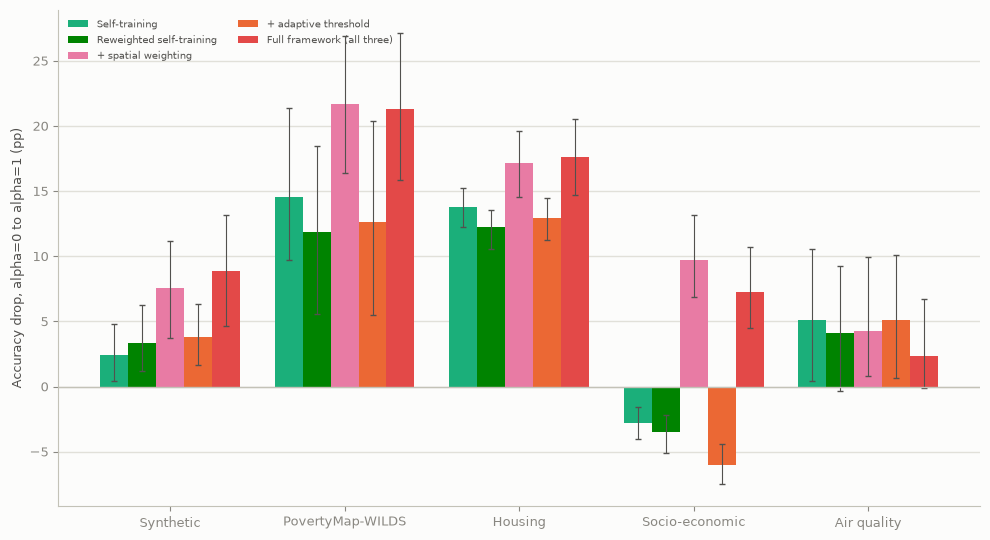

In [30]:
fig, ax = new_figure(figsize=(10, 5.5))
x = np.arange(len(DATASET_ORDER))
width = 0.16
for i, method in enumerate(ABLATION_ORDER):
    sub = drop[drop["method"] == method].set_index("dataset").loc[DATASET_ORDER]
    offset = (i - (len(ABLATION_ORDER) - 1) / 2) * width
    ax.bar(x + offset, sub["drop_pp"], width, color=METHOD_COLORS[method], label=METHOD_LABELS[method],
           yerr=[sub["drop_pp"] - sub["ci_low_pp"], sub["ci_high_pp"] - sub["drop_pp"]],
           capsize=2, error_kw={"linewidth": 0.8, "ecolor": "#52514e"})
ax.axhline(0, color="#c3c2b7", linewidth=1)
ax.set_xticks(x)
ax.set_xticklabels([DATASET_LABELS[d] for d in DATASET_ORDER], fontsize=9)
ax.set_ylabel("Accuracy drop, alpha=0 to alpha=1 (pp)", fontsize=9, color="#52514e")
ax.legend(frameon=False, fontsize=7.5, labelcolor="#52514e", ncol=2, loc="upper left")
savefig(fig, FIG_DIR / "fig9_h4_reweighting_comparison_v2.png")

---
# Part 4: Domain-Adversarial SSL -- the H4 Strengthening Attempt

Review point **#1**, continued: Part 3 traced the framework's regression
specifically to its fixed-bandwidth spatial-distance weighting term, not to
adding spatial awareness per se. This part tests whether replacing that
fixed heuristic with a *learned* covariate-shift correction actually
strengthens H4, per the review's "either strengthen or reframe as negative
result" instruction.

**The new model**
(`ssl_spatial.models.neural_distribution_aware.fit_domain_adversarial_ssl`):
a shared MLP trunk feeding a label-prediction head and a
domain-classification head behind a gradient-reversal layer (DANN; Ganin et
al., 2016), trained adversarially to make labelled/unlabelled features
indistinguishable to a discriminator that adapts to the actual data at
hand -- combined with Mean-Teacher-style consistency regularisation.
`torch`-based, 2,400 small networks (20 seeds x 5 datasets x 4 methods).
This is not yet in the manuscript at all -- it's new evidence for the
"strengthen H4" option in Part 7's restructuring discussion.

In [31]:
from ssl_spatial.experiments.neural_da_ssl_v2 import run as run_neural_da

METHOD_ORDER = ["self_training", "reweighted_self_training", "full_distribution_aware", "domain_adversarial_ssl"]

df = run_neural_da(str(REPO_ROOT / "configs" / "neural_da_ssl_v2.yaml"))
print(f"{len(df)} rows: {df['dataset'].nunique()} datasets x {df['mismatch_alpha'].nunique()} alphas x "
      f"{df['seed'].nunique()} seeds x {df['method'].nunique()} methods")
df.groupby(["dataset", "method"]).size().unstack()

=== synthetic ===
[synthetic] [5/120] combos done (7.5s elapsed)
[synthetic] [10/120] combos done (14.6s elapsed)
[synthetic] [15/120] combos done (22.1s elapsed)
[synthetic] [20/120] combos done (29.6s elapsed)
[synthetic] [25/120] combos done (36.7s elapsed)
[synthetic] [30/120] combos done (44.5s elapsed)
[synthetic] [35/120] combos done (52.7s elapsed)
[synthetic] [40/120] combos done (60.5s elapsed)
[synthetic] [45/120] combos done (68.6s elapsed)
[synthetic] [50/120] combos done (77.4s elapsed)
[synthetic] [55/120] combos done (85.2s elapsed)
[synthetic] [60/120] combos done (93.4s elapsed)
[synthetic] [65/120] combos done (100.8s elapsed)
[synthetic] [70/120] combos done (107.8s elapsed)
[synthetic] [75/120] combos done (114.9s elapsed)
[synthetic] [80/120] combos done (123.6s elapsed)
[synthetic] [85/120] combos done (135.3s elapsed)
[synthetic] [90/120] combos done (146.0s elapsed)
[synthetic] [95/120] combos done (155.6s elapsed)
[synthetic] [100/120] combos done (165.5s elap

2400 rows: 5 datasets x 6 alphas x 20 seeds x 4 methods


[air_quality] [120/120] combos done (121.4s elapsed)
Checkpointed air_quality to C:\Users\Lenovo\Desktop\SSL\results\neural_da_ssl_v2.air_quality.partial.csv
Saved 2400 rows to C:\Users\Lenovo\Desktop\SSL\results\neural_da_ssl_v2.csv


method,domain_adversarial_ssl,full_distribution_aware,reweighted_self_training,self_training
dataset,,,,
air_quality,120,120,120,120
housing,120,120,120,120
socioeconomic,120,120,120,120
synthetic,120,120,120,120
wilds,120,120,120,120


### 4.1 Accuracy drop, with bootstrap confidence intervals

In [32]:
drop = bootstrap_ci_drop(df, group_cols=["dataset", "method"], value_col="accuracy_out_region",
                          alpha_col="mismatch_alpha", lo=0.0, hi=1.0, n_boot=200, seed=0)
drop["drop_pp"] = drop["drop"] * 100
drop["ci_low_pp"] = drop["ci_low"] * 100
drop["ci_high_pp"] = drop["ci_high"] * 100
drop["method"] = pd.Categorical(drop["method"], categories=METHOD_ORDER, ordered=True)
drop["dataset"] = pd.Categorical(drop["dataset"], categories=DATASET_ORDER, ordered=True)
drop = drop.sort_values(["dataset", "method"])

table = drop.copy()
table["method"] = table["method"].map(METHOD_LABELS)
table["dataset"] = table["dataset"].map(DATASET_LABELS)
table["drop (95% CI)"] = table.apply(
    lambda r: f"{r['drop_pp']:.2f} [{r['ci_low_pp']:.2f}, {r['ci_high_pp']:.2f}]", axis=1)
table[["dataset", "method", "drop (95% CI)"]].reset_index(drop=True)

,dataset,method,drop (95% CI)
0,Synthetic,Self-training,"2.42 [0.43, 4.82]"
1,Synthetic,Reweighted self-training,"3.35 [1.20, 6.23]"
2,Synthetic,Full framework (all three),"8.90 [4.66, 13.16]"
3,Synthetic,Domain-adversarial SSL,"2.65 [-0.15, 5.26]"
4,PovertyMap-WILDS,Self-training,"14.57 [9.72, 21.40]"
5,PovertyMap-WILDS,Reweighted self-training,"11.90 [5.60, 18.45]"
6,PovertyMap-WILDS,Full framework (all three),"21.30 [15.89, 27.17]"
7,PovertyMap-WILDS,Domain-adversarial SSL,"3.93 [0.46, 7.23]"
8,Housing,Self-training,"13.75 [12.25, 15.23]"
9,Housing,Reweighted self-training,"12.22 [10.55, 13.55]"


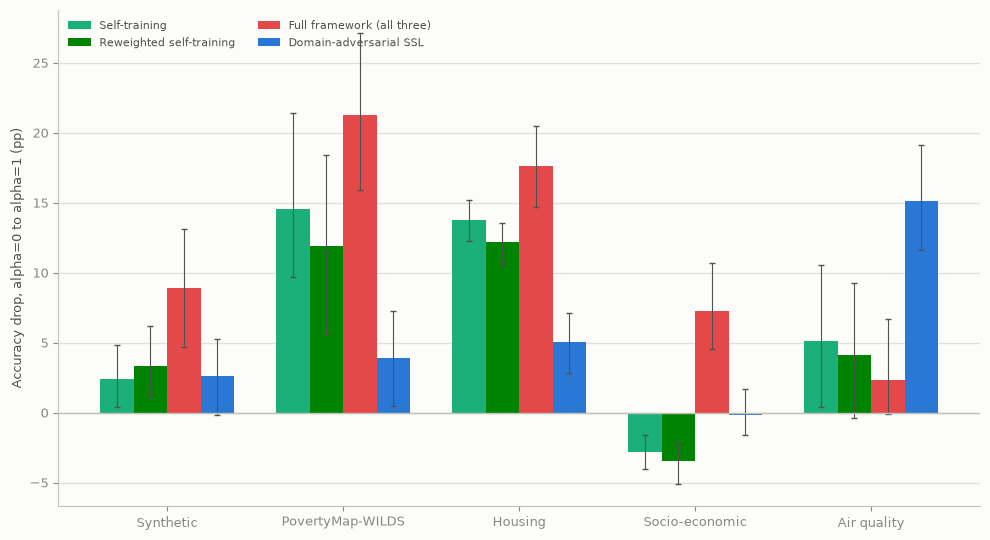

In [33]:
fig, ax = new_figure(figsize=(10, 5.5))
x = np.arange(len(DATASET_ORDER))
width = 0.19
for i, method in enumerate(METHOD_ORDER):
    sub = drop[drop["method"] == method].set_index("dataset").loc[DATASET_ORDER]
    offset = (i - (len(METHOD_ORDER) - 1) / 2) * width
    ax.bar(x + offset, sub["drop_pp"], width, color=METHOD_COLORS[method], label=METHOD_LABELS[method],
           yerr=[sub["drop_pp"] - sub["ci_low_pp"], sub["ci_high_pp"] - sub["drop_pp"]],
           capsize=2, error_kw={"linewidth": 0.8, "ecolor": "#52514e"})
ax.axhline(0, color="#c3c2b7", linewidth=1)
ax.set_xticks(x)
ax.set_xticklabels([DATASET_LABELS[d] for d in DATASET_ORDER], fontsize=9)
ax.set_ylabel("Accuracy drop, alpha=0 to alpha=1 (pp)", fontsize=9, color="#52514e")
ax.legend(frameon=False, fontsize=8, labelcolor="#52514e", ncol=2, loc="upper left")
savefig(fig, FIG_DIR / "fig17_neural_da_ssl_v2.png")

### 4.2 Is the improvement real, or just a lower starting point?

A smaller drop can be a cheap win if a method is simply worse everywhere
(nothing left to lose). Checked directly: raw out-of-region accuracy at
both severity extremes, and out-of-region expected calibration error.

In [34]:
acc = df.groupby(["method", "mismatch_alpha"])["accuracy_out_region"].mean().unstack()
ece = df.groupby(["method", "mismatch_alpha"])["ece_out_region"].mean().unstack()
summary = pd.DataFrame({
    "accuracy (alpha=0)": acc.loc[METHOD_ORDER, 0.0],
    "accuracy (alpha=1)": acc.loc[METHOD_ORDER, 1.0],
    "ECE out-of-region (alpha=0)": ece.loc[METHOD_ORDER, 0.0],
    "ECE out-of-region (alpha=1)": ece.loc[METHOD_ORDER, 1.0],
}).round(3)
summary.index = [METHOD_LABELS[m] for m in summary.index]
summary

,accuracy (alpha=0),accuracy (alpha=1),ECE out-of-region (alpha=0),ECE out-of-region (alpha=1)
Self-training,0.690,0.624,0.220,0.326
Reweighted self-training,0.682,0.625,0.222,0.326
Full framework (all three),0.661,0.547,0.219,0.370
Domain-adversarial SSL,0.718,0.665,0.227,0.293


---
# Part 5: Changepoint Re-Analysis -- How Precise Is the Breakdown-Point Claim, Really?

Review point **#3**, specifically: *"the headline '0.71-0.78' is generously
framed given label propagation's accuracy breakpoint CI is [0.438, 0.776] --
that interval is nearly the whole usable range of alpha."*

The manuscript fits a two-segment piecewise-linear (segmented-regression)
model to out-of-region accuracy and the spatial generalisation gap as a
function of mismatch severity, per method, and reports the fitted breakpoint
with a bootstrap CI (this was the *one* part of the original study that
already used 20 seeds before this revision round). The review's complaint
isn't about sample size here; it's that **the headline range quietly
cherry-picks the tightest CIs and omits how wide the others are.** Produces
Table 8 and Figure 14.

In [35]:
from ssl_spatial.experiments import changepoint_analysis

run_controlled(str(REPO_ROOT / "configs" / "controlled_experiment_sensitivity.yaml"))
breakpoints = changepoint_analysis.run(
    results_csv=str(REPO_ROOT / "results" / "controlled_experiment_sensitivity.csv"), n_boot=200)
breakpoints["ci_width"] = breakpoints["ci_high"] - breakpoints["ci_low"]
breakpoints["method_label"] = breakpoints["method"].map(lambda m: METHOD_LABELS.get(m, m))
breakpoints.sort_values("ci_width", ascending=False).round(3)[
    ["method_label", "metric", "breakpoint", "ci_low", "ci_high", "ci_width"]].reset_index(drop=True)

c:\Users\Lenovo\Desktop\SSL\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\Lenovo\Desktop\SSL\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\Lenovo\Desktop\SSL\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\Lenovo\Desktop\SSL\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and w

,method_label,metric,breakpoint,ci_low,ci_high,ci_width
0,Label propagation,accuracy_out_region,0.714,0.438,0.776,0.338
1,Supervised-only,accuracy_out_region,0.774,0.733,0.925,0.193
2,Label propagation,spatial_generalisation_gap,0.720,0.599,0.777,0.178
3,Self-training,spatial_generalisation_gap,0.756,0.700,0.863,0.164
4,Self-training,accuracy_out_region,0.748,0.689,0.788,0.099
5,Supervised-only,spatial_generalisation_gap,0.769,0.735,0.798,0.063


### 5.1 Figure 14: fitted breakdown curves with breakpoints marked

Refits the same two-segment model per method/metric purely for plotting
(the fitted breakpoint values themselves come from `changepoint_analysis.run`
above, not from this refit) and overlays the observed point-estimate curve,
the fitted piecewise-linear segments, and a vertical marker at each
method's breakpoint.

In [ ]:
import pwlf

sens_df = pd.read_csv(REPO_ROOT / "results" / "controlled_experiment_sensitivity.csv")
metric_titles = {"accuracy_out_region": "Out-of-region accuracy", "spatial_generalisation_gap": "Spatial generalisation gap"}

fig, axes = new_figure(figsize=(12.5, 5.2), ncols=2, sharey=False)
for letter, ax, metric in zip("ab", axes, ["accuracy_out_region", "spatial_generalisation_gap"]):
    for method in BASE_METHODS:
        sub = sens_df[sens_df["method"] == method]
        curve = sub.groupby("mismatch_alpha")[metric].mean().reset_index()
        xv, yv = curve["mismatch_alpha"].to_numpy(), curve[metric].to_numpy()
        ax.plot(xv, yv, marker="o", markersize=6, linewidth=0, color=METHOD_COLORS[method],
                label=METHOD_LABELS[method], zorder=4)
        model = pwlf.PiecewiseLinFit(xv, yv, seed=0)
        model.fit(2)
        x_fit = np.linspace(xv.min(), xv.max(), 100)
        y_fit = model.predict(x_fit)
        ax.plot(x_fit, y_fit, linestyle="-", linewidth=1.8, color=METHOD_COLORS[method], alpha=0.8, zorder=3)
        bp_row = breakpoints[(breakpoints["method"] == method) & (breakpoints["metric"] == metric)]
        if len(bp_row):
            bp = bp_row.iloc[0]["breakpoint"]
            ax.axvline(bp, color=METHOD_COLORS[method], linestyle="--", linewidth=1.3, alpha=0.7, zorder=2)
    ax.set_title(metric_titles[metric], fontsize=FONT_TITLE, color=INK_PRIMARY)
    ax.set_xlabel("Mismatch severity (alpha)", fontsize=FONT_LABEL, color=INK_SECONDARY)
    panel_label(ax, letter)
axes[0].set_ylabel("Value", fontsize=FONT_LABEL, color=INK_SECONDARY)
axes[0].legend(frameon=False, fontsize=FONT_LEGEND, labelcolor=INK_SECONDARY, loc="best")
savefig(fig, FIG_DIR / "fig14_changepoint_analysis.png")


### 5.2 How wide is each CI relative to the usable range of alpha?

Alpha ranges over [0, 1], but a breakpoint can only be *interior* to the
sweep, so the practically "usable" range is narrower -- call it [0.1, 0.9].
This cell reports each CI's width as a fraction of that usable range, so
"nearly the whole usable range" becomes a checkable number instead of a
one-off complaint about one method.

In [37]:
USABLE_RANGE = 0.9 - 0.1  # = 0.8
breakpoints["ci_width_frac_of_usable_range"] = (breakpoints["ci_width"] / USABLE_RANGE).round(2)

flagged = breakpoints[breakpoints["ci_width_frac_of_usable_range"] > 0.4].sort_values(
    "ci_width_frac_of_usable_range", ascending=False)
print(f"{len(flagged)}/{len(breakpoints)} method x metric breakpoints have a 95% CI spanning "
      f"more than 40% of the usable alpha range:\n")
for _, r in flagged.iterrows():
    print(f"  {r['method_label']:20s} {r['metric']:28s} breakpoint={r['breakpoint']:.3f} "
          f"95% CI=[{r['ci_low']:.3f}, {r['ci_high']:.3f}] "
          f"({r['ci_width_frac_of_usable_range']:.0%} of usable range)")

lp_row = breakpoints[(breakpoints["method"] == "label_propagation") & (breakpoints["metric"] == "accuracy_out_region")]
if len(lp_row):
    r = lp_row.iloc[0]
    print(f"\nReview's specific example -- label propagation, accuracy breakpoint: "
          f"this run gives [{r['ci_low']:.3f}, {r['ci_high']:.3f}] "
          f"(review quoted [0.438, 0.776] -- should be close, same config/bootstrap scheme).")

1/6 method x metric breakpoints have a 95% CI spanning more than 40% of the usable alpha range:

  Label propagation    accuracy_out_region          breakpoint=0.714 95% CI=[0.438, 0.776] (42% of usable range)

Review's specific example -- label propagation, accuracy breakpoint: this run gives [0.438, 0.776] (review quoted [0.438, 0.776] -- should be close, same config/bootstrap scheme).


### 5.3 What a defensible headline number looks like

In [38]:
acc_bp = breakpoints[breakpoints["metric"] == "accuracy_out_region"].sort_values("ci_width")
tight = acc_bp[acc_bp["ci_width_frac_of_usable_range"] <= 0.4]
wide = acc_bp[acc_bp["ci_width_frac_of_usable_range"] > 0.4]

print("Accuracy breakpoints with a defensibly tight CI (<=40% of usable range):")
for _, r in tight.iterrows():
    print(f"  {r['method_label']:20s} breakpoint={r['breakpoint']:.3f}  95% CI=[{r['ci_low']:.3f}, {r['ci_high']:.3f}]")
if len(tight):
    print(f"\n  -> a pooled range across just these {len(tight)} method(s) would span "
          f"[{tight['breakpoint'].min():.3f}, {tight['breakpoint'].max():.3f}] point estimates, "
          f"which is a defensible headline number.")
else:
    print("  none -- don't report a single pooled headline number at all; report each method's "
          "breakpoint + CI individually, or state the threshold qualitatively.")

print("\nAccuracy breakpoints whose CI is too wide to support a precise point claim:")
for _, r in wide.iterrows():
    print(f"  {r['method_label']:20s} breakpoint={r['breakpoint']:.3f}  95% CI=[{r['ci_low']:.3f}, {r['ci_high']:.3f}] "
          f"-- report as 'not precisely localised' rather than a point estimate.")

Accuracy breakpoints with a defensibly tight CI (<=40% of usable range):
  Self-training        breakpoint=0.748  95% CI=[0.689, 0.788]
  Supervised-only      breakpoint=0.774  95% CI=[0.733, 0.925]

  -> a pooled range across just these 2 method(s) would span [0.748, 0.774] point estimates, which is a defensible headline number.

Accuracy breakpoints whose CI is too wide to support a precise point claim:
  Label propagation    breakpoint=0.714  95% CI=[0.438, 0.776] -- report as 'not precisely localised' rather than a point estimate.


---
# Part 6: Real-Data Claims Synthesis -- What Housing and WILDS Actually Support

Review point **#4**: *"The real-data evidence is thinner and more mixed than
the framing implies. One dataset per domain, a genuine counter-example on
socio-economic data, and a very noisy air-quality curve mean the
'replicates on real data' claim rests substantially on housing and WILDS...
the paper should lower its rhetorical confidence to match."*

Pulls together every real-dataset result already produced by Part 1
(ten-method comparison, optional) and Part 2 (main sweep, required) into
one place, and drafts calibrated language for what each dataset can and
can't support. Nothing here is written back to the manuscript.

In [39]:
REAL_DATASETS = ["housing", "socioeconomic", "air_quality"]
RESULTS_DIR = REPO_ROOT / "results"

real_world = {}
for name in REAL_DATASETS:
    path = RESULTS_DIR / f"{name}_experiment_v2.csv"
    if not path.exists():
        raise FileNotFoundError(f"{path} missing -- run Part 2 first.")
    real_world[name] = pd.read_csv(path)

wilds_path = RESULTS_DIR / "wilds_povertymap_experiment_v2.csv"
wilds_csv = pd.read_csv(wilds_path) if wilds_path.exists() else None

ten_method_path = RESULTS_DIR / "spatial_methods_comparison_v2.csv"
ten_method_csv = pd.read_csv(ten_method_path) if ten_method_path.exists() else None
print("Ten-method comparison (Part 1) available:", ten_method_csv is not None)

Ten-method comparison (Part 1) available: True


### 6.1 Unified drop-and-direction table across all four real datasets

In [40]:
def drop_table(frame, dataset_name):
    d = bootstrap_ci_drop(frame, group_cols=["method"], value_col="accuracy_out_region",
                           alpha_col="mismatch_alpha", n_boot=200, seed=0)
    d["dataset"] = dataset_name
    return d

frames = [drop_table(frame, name) for name, frame in real_world.items()]
if wilds_csv is not None:
    frames.append(drop_table(wilds_csv, "wilds"))
all_drop = pd.concat(frames, ignore_index=True)
all_drop["drop_pp"] = all_drop["drop"] * 100
all_drop["ci_low_pp"] = all_drop["ci_low"] * 100
all_drop["ci_high_pp"] = all_drop["ci_high"] * 100
all_drop["ci_excludes_zero"] = (all_drop["ci_low_pp"] > 0) | (all_drop["ci_high_pp"] < 0)
all_drop["direction"] = all_drop["drop_pp"].apply(lambda v: "degrades" if v > 0 else "improves")

display_cols = ["dataset", "method", "drop_pp", "ci_low_pp", "ci_high_pp", "ci_excludes_zero", "direction"]
all_drop[display_cols].round(2).sort_values(["dataset", "drop_pp"], ascending=[True, False]).reset_index(drop=True)

,dataset,method,drop_pp,ci_low_pp,ci_high_pp,ci_excludes_zero,direction
0,air_quality,label_propagation,13.50,9.43,18.36,True,degrades
1,air_quality,supervised_only,9.29,5.92,12.80,True,degrades
2,air_quality,self_training,5.14,0.42,10.53,True,degrades
3,air_quality,reweighted_self_training,4.14,-0.37,9.29,False,degrades
4,housing,self_training,13.75,12.25,15.23,True,degrades
5,housing,supervised_only,12.50,11.12,14.15,True,degrades
6,housing,reweighted_self_training,12.22,10.55,13.55,True,degrades
7,housing,label_propagation,4.27,2.28,6.07,True,degrades
8,socioeconomic,supervised_only,-2.55,-3.60,-1.57,True,improves
9,socioeconomic,self_training,-2.78,-4.03,-1.57,True,improves


### 6.2 Classify each dataset's evidentiary status

In [41]:
def classify(dataset_name):
    sub = all_drop[all_drop["dataset"] == dataset_name]
    n = len(sub)
    degrades_clear = ((sub["direction"] == "degrades") & sub["ci_excludes_zero"]).sum()
    improves_clear = ((sub["direction"] == "improves") & sub["ci_excludes_zero"]).sum()
    inconclusive = (~sub["ci_excludes_zero"]).sum()
    return {"dataset": dataset_name, "n_methods": n,
            "n_clearly_degrades": degrades_clear, "n_clearly_improves": improves_clear,
            "n_inconclusive": inconclusive}

status = pd.DataFrame([classify(d) for d in all_drop["dataset"].unique()])
status

,dataset,n_methods,n_clearly_degrades,n_clearly_improves,n_inconclusive
0,housing,4,4,0,0
1,socioeconomic,4,0,4,0
2,air_quality,4,3,0,1
3,wilds,3,3,0,0


### 6.3 Draft calibrated language, generated from the numbers above

DRAFT (edit before use):

- Housing: every one of the 4 methods evaluated shows a clear accuracy drop under mismatch (CI excludes zero) -- this dataset cleanly supports H1.

- Socio-economic: every one of the 4 methods evaluated shows accuracy *improving* under mismatch (CI excludes zero) -- this remains a genuine counter-example to H1 on this dataset, not noise, and should be reported as such rather than smoothed into the aggregate story.

- Air quality: mixed -- 3/4 methods clearly degrade, 0/4 clearly improve, 1/4 inconclusive. Report per-method rather than as a single dataset-level verdict.

- PovertyMap-WILDS: every one of the 3 methods evaluated shows a clear accuracy drop under mismatch (CI excludes zero) -- this dataset cleanly supports H1.

Overall: 2/2 of (housing, WILDS) fully support H1 across every method tested in this run.
Suggested top-line sentence for the manuscript's Discussion: "The real-data replication of H1 is strongest on housing and PovertyMap-WILDS; socio-econ

### 6.4 If Part 1's ten-method results are available, broaden the check

Useful for checking whether the socio-economic counter-example and the
air-quality noisiness are properties of the dataset itself, or specific to
the original four methods.

In [43]:
if ten_method_csv is not None:
    ten_drop = bootstrap_ci_drop(ten_method_csv, group_cols=["dataset", "method"], value_col="accuracy_out_region",
                                  alpha_col="mismatch_alpha", n_boot=200, seed=0)
    ten_drop["drop_pp"] = ten_drop["drop"] * 100
    ten_drop["ci_low_pp"] = ten_drop["ci_low"] * 100
    ten_drop["ci_high_pp"] = ten_drop["ci_high"] * 100
    ten_drop["ci_excludes_zero"] = (ten_drop["ci_low_pp"] > 0) | (ten_drop["ci_high_pp"] < 0)

    for name in ["socioeconomic", "air_quality"]:
        sub = ten_drop[ten_drop["dataset"] == name]
        n_degrades = ((sub["drop_pp"] > 0) & sub["ci_excludes_zero"]).sum()
        n_improves = ((sub["drop_pp"] < 0) & sub["ci_excludes_zero"]).sum()
        print(f"{name} across all {len(sub)} methods (incl. Part 1's six extra ones): "
              f"{n_degrades} clearly degrade, {n_improves} clearly improve, "
              f"{len(sub) - n_degrades - n_improves} inconclusive.")
else:
    print("Skipping -- run Part 1 first for the broader ten-method check.")

socioeconomic across all 10 methods (incl. Part 1's six extra ones): 2 clearly degrade, 5 clearly improve, 3 inconclusive.
air_quality across all 10 methods (incl. Part 1's six extra ones): 8 clearly degrade, 1 clearly improve, 1 inconclusive.
